In [3]:
import numpy as np
import matplotlib.pyplot as plt
import kwant

from pathlib import Path
from scipy.sparse.linalg import eigsh


FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

In [4]:
# Model parameters (Energies in meV)

t_sq = 2678.0
t_link = 2980.0
t_diag = 548.0

Delta = 50.0

mu_star = -2420.0
mu_lead = mu_star + 250.0

eps_d = 500.0
V = 800.0

Nx = 10
Ny = 6

J_device = 600.0

In [5]:
# BdG matrices

s0 = np.eye(2, dtype=complex)

sy = np.array([
    [0, -1j],
    [1j, 0]
], dtype=complex)

sz = np.array([
    [1, 0],
    [0, -1]
], dtype=complex)

z2 = np.zeros((2, 2), dtype=complex)


# Electron-hole conservation law in the normal leads
tau_z = np.diag([1, 1, -1, -1]).astype(complex)
Q_eh = -tau_z

ELECTRON = 0
HOLE = 1


# Square-octagon lattice

rt2 = np.sqrt(2)
a = 1 + rt2

lat = kwant.lattice.general(
    [(a, 0), (0, a)],
    [
        (0, 1 / rt2),
        (-1 / rt2, 0),
        (0, -1 / rt2),
        (1 / rt2, 0)
    ],
    norbs=4,
    name="sqoct"
)

A, B, C, D = lat.sublattices


ad_lat = kwant.lattice.general(
    [(a, 0), (0, a)],
    [(0, 0)],
    norbs=4,
    name="adatom"
)

AD = ad_lat.sublattices[0]

In [6]:
def onsite_SC(site, mu, Delta):

    h = -mu * s0
    pair = 1j * Delta * sy

    return np.block([
        [h, pair],
        [pair.conj().T, -h.T]
    ])


def onsite_normal(site, mu_lead):

    h = -mu_lead * s0

    return np.block([
        [h, z2],
        [z2, -h.T]
    ])


def onsite_adatom(site, eps_d, Jd):

    h = eps_d * s0 + Jd * sz

    return np.block([
        [h, z2],
        [z2, -h.T]
    ])


def bdg_hopping(he):

    return np.block([
        [he, z2],
        [z2, -he.conj()]
    ])


HOP_SQ = bdg_hopping(-t_sq * s0)
HOP_LINK = bdg_hopping(-t_link * s0)
HOP_DIAG = bdg_hopping(-t_diag * s0)

In [7]:
def make_normal_lead(Ny):

    sym = kwant.TranslationalSymmetry(lat.vec((-1, 0)))

    lead = kwant.Builder(
        sym,
        conservation_law=Q_eh
    )

    # Sites and intra-cell hoppings
    for iy in range(Ny):

        lead[A(0, iy)] = onsite_normal
        lead[B(0, iy)] = onsite_normal
        lead[C(0, iy)] = onsite_normal
        lead[D(0, iy)] = onsite_normal

        lead[A(0, iy), B(0, iy)] = HOP_SQ
        lead[B(0, iy), C(0, iy)] = HOP_SQ
        lead[C(0, iy), D(0, iy)] = HOP_SQ
        lead[D(0, iy), A(0, iy)] = HOP_SQ

        lead[A(0, iy), C(0, iy)] = HOP_DIAG
        lead[B(0, iy), D(0, iy)] = HOP_DIAG

        # Hopping between lead unit cells
        lead[B(-1, iy), D(0, iy)] = HOP_LINK

    # Vertical links
    for iy in range(Ny - 1):
        lead[C(0, iy), A(0, iy + 1)] = HOP_LINK

    return lead

In [8]:
def adsorption_cluster(geometry, ix, iy):

    if geometry == "Top":
        return [A(ix, iy)]

    if geometry == "Square":
        return [
            A(ix, iy), B(ix, iy),
            C(ix, iy), D(ix, iy)
        ]

    if geometry == "Octagon":
        return [
            D(ix, iy), B(ix + 1, iy),
            A(ix + 1, iy), C(ix + 1, iy + 1),
            B(ix + 1, iy + 1), D(ix, iy + 1),
            C(ix, iy + 1), A(ix, iy)
        ]

    raise ValueError("geometry must be Top, Square, or Octagon")

In [9]:
def make_device(Nx, Ny, geometry=None, leads=True):

    syst = kwant.Builder()

    # Superconducting host

    for ix in range(Nx):
        for iy in range(Ny):

            syst[A(ix, iy)] = onsite_SC
            syst[B(ix, iy)] = onsite_SC
            syst[C(ix, iy)] = onsite_SC
            syst[D(ix, iy)] = onsite_SC

    # Host hoppings

    for ix in range(Nx):
        for iy in range(Ny):

            syst[A(ix, iy), B(ix, iy)] = HOP_SQ
            syst[B(ix, iy), C(ix, iy)] = HOP_SQ
            syst[C(ix, iy), D(ix, iy)] = HOP_SQ
            syst[D(ix, iy), A(ix, iy)] = HOP_SQ

            syst[A(ix, iy), C(ix, iy)] = HOP_DIAG
            syst[B(ix, iy), D(ix, iy)] = HOP_DIAG

            if iy < Ny - 1:
                syst[C(ix, iy), A(ix, iy + 1)] = HOP_LINK

            if ix < Nx - 1:
                syst[B(ix, iy), D(ix + 1, iy)] = HOP_LINK

    # Magnetic adatom

    ad_site = None
    cluster = None

    if geometry is not None:

        ix0 = Nx // 2 - 1
        iy0 = Ny // 2 - 1

        cluster = adsorption_cluster(geometry, ix0, iy0)

        ad_site = AD(ix0, iy0)
        syst[ad_site] = onsite_adatom

        Nc = len(cluster)
        hyb = bdg_hopping((V / np.sqrt(Nc)) * s0)

        for host_site in cluster:
            syst[ad_site, host_site] = hyb

    # Normal leads

    if leads:

        lead = make_normal_lead(Ny)

        syst.attach_lead(lead)
        syst.attach_lead(lead.reversed())

    return syst.finalized(), ad_site, cluster

In [10]:
def nonlocal_conductance(fsyst, energy, params):

    smat = kwant.smatrix(
        fsyst,
        energy=energy,
        params=params
    )

    Tee = smat.transmission(
        (1, ELECTRON),
        (0, ELECTRON)
    )

    The = smat.transmission(
        (1, HOLE),
        (0, ELECTRON)
    )

    return Tee - The

In [11]:
clean_dev, _, _ = make_device(
    Nx, Ny,
    geometry=None
)

top_dev, top_ad, top_cluster = make_device(
    Nx, Ny,
    geometry="Top"
)

sq_dev, sq_ad, sq_cluster = make_device(
    Nx, Ny,
    geometry="Square"
)

oct_dev, oct_ad, oct_cluster = make_device(
    Nx, Ny,
    geometry="Octagon"
)


base_params = {
    "mu": mu_star,
    "Delta": Delta,
    "mu_lead": mu_lead,
    "eps_d": eps_d,
    "Jd": J_device
}

In [12]:
# Device schematic

cluster = set(sq_cluster)


def site_color(site):

    if site == sq_ad:
        return "#C44E52"

    if site in cluster:
        return "#D9822B"

    return "0.30"


def site_size(site):

    if site == sq_ad:
        return 0.55

    if site in cluster:
        return 0.34

    return 0.18

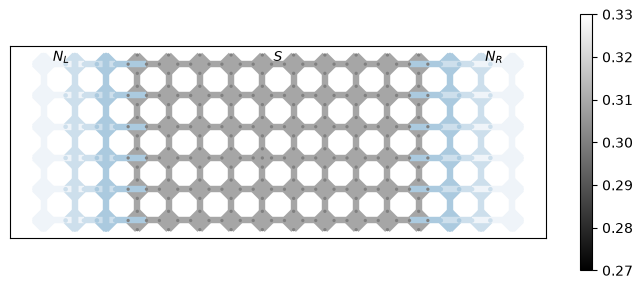

In [13]:
fig = kwant.plot(
    sq_dev,
    num_lead_cells=3,
    site_color=site_color,
    site_size=site_size,
    hop_color="0.65",
    hop_lw=0.7,
    lead_color="#9BBFD9",
    show=False
)

ax = fig.axes[0]

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

ax.text(
    xmin + 0.08 * (xmax - xmin),
    ymax - 0.08 * (ymax - ymin),
    r"$N_L$", fontweight="bold"
)

ax.text(
    0.5 * (xmin + xmax),
    ymax - 0.08 * (ymax - ymin),
    r"$S$", ha="center", fontweight="bold"
)

ax.text(
    xmax - 0.08 * (xmax - xmin),
    ymax - 0.08 * (ymax - ymin),
    r"$N_R$", ha="right", fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])

fig.set_size_inches(7, 3)
fig.tight_layout()

# fig.savefig(
#     FIG_DIR / "device_kwant_schematic.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()

In [14]:
energies = np.linspace(
    -0.25 * Delta,
    0.25 * Delta,
    121
)


G_clean = np.array([
    nonlocal_conductance(clean_dev, E, base_params)
    for E in energies
])

G_top = np.array([
    nonlocal_conductance(top_dev, E, base_params)
    for E in energies
])

G_square = np.array([
    nonlocal_conductance(sq_dev, E, base_params)
    for E in energies
])

G_octagon = np.array([
    nonlocal_conductance(oct_dev, E, base_params)
    for E in energies
])

x = energies / Delta

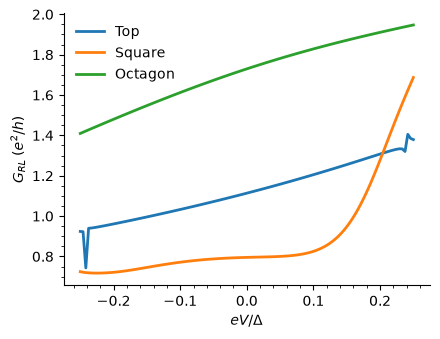

In [15]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))


ax.plot(x, G_top, lw=2, label="Top")
ax.plot(x, G_square, lw=2, label="Square")
ax.plot(x, G_octagon, lw=2, label="Octagon")

ax.set_xlabel(r"$eV/\Delta$")
ax.set_ylabel(r"$G_{RL}\;(e^2/h)$")

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.minorticks_on()

plt.tight_layout()

# plt.savefig(
#     FIG_DIR / "device_nonlocal_conductance.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()

In [16]:
dG_top = G_top - G_clean
dG_square = G_square - G_clean
dG_octagon = G_octagon - G_clean

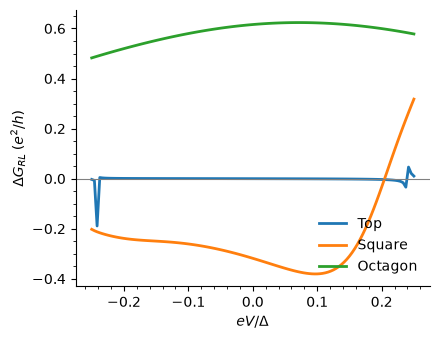

In [17]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))


ax.plot(x, dG_top, lw=2, label="Top")
ax.plot(x, dG_square, lw=2, label="Square")
ax.plot(x, dG_octagon, lw=2, label="Octagon")

ax.axhline(0, color="gray", lw=0.8)

ax.set_xlabel(r"$eV/\Delta$")
ax.set_ylabel(r"$\Delta G_{RL}\;(e^2/h)$")

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.minorticks_on()

plt.tight_layout()

# plt.savefig(
#     FIG_DIR / "device_delta_conductance.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()

In [18]:
J_scan = np.linspace(500.0, 720.0, 45)

G0_clean = nonlocal_conductance(
    clean_dev, 0.0,
    base_params
)

In [19]:
deltaG_top = []
deltaG_square = []
deltaG_octagon = []


for Jd in J_scan:

    p = dict(base_params)
    p["Jd"] = Jd

    deltaG_top.append(
        nonlocal_conductance(top_dev, 0.0, p) - G0_clean
    )

    deltaG_square.append(
        nonlocal_conductance(sq_dev, 0.0, p) - G0_clean
    )

    deltaG_octagon.append(
        nonlocal_conductance(oct_dev, 0.0, p) - G0_clean
    )


deltaG_top = np.array(deltaG_top)
deltaG_square = np.array(deltaG_square)
deltaG_octagon = np.array(deltaG_octagon)

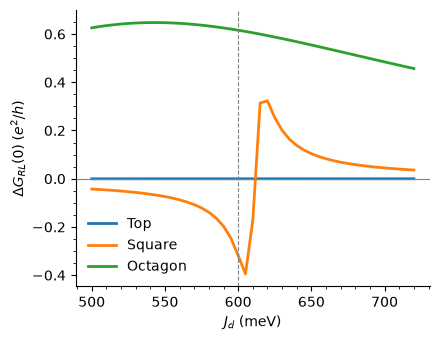

In [20]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))


ax.plot(J_scan, deltaG_top, lw=2, label="Top")
ax.plot(J_scan, deltaG_square, lw=2, label="Square")
ax.plot(J_scan, deltaG_octagon, lw=2, label="Octagon")

ax.axhline(0, color="gray", lw=0.8)
ax.axvline(J_device, color="gray", ls="--", lw=0.8)

ax.set_xlabel(r"$J_d$ (meV)")
ax.set_ylabel(r"$\Delta G_{RL}(0)\;(e^2/h)$")

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.minorticks_on()

plt.tight_layout()

# plt.savefig(
#     FIG_DIR / "device_zero_bias_response.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()

In [21]:
closed_sq, closed_sq_ad, _ = make_device(
    Nx, Ny,
    geometry="Square",
    leads=False
)

In [22]:
def square_impurity_energy(fsyst, ad_site, params):

    H = fsyst.hamiltonian_submatrix(
        params=params,
        sparse=True
    )

    vals, vecs = eigsh(
        H, k=40,
        sigma=1e-6, which="LM",
        tol=1e-9, maxiter=60000
    )

    order = np.argsort(np.abs(vals))

    vals = vals[order].real
    vecs = vecs[:, order]


    # Adatom weight of each state
    iad = fsyst.id_by_site[ad_site]
    ad_slice = slice(4 * iad, 4 * iad + 4)

    Wd = np.array([
        np.sum(np.abs(vecs[ad_slice, n])**2).real
        for n in range(len(vals))
    ])


    # Positive-energy impurity state close to the gap
    candidates = np.where(
        (vals >= 0) & (vals < 3 * Delta)
    )[0]

    if len(candidates) == 0:
        candidates = np.where(vals >= 0)[0]

    index = candidates[
        np.argmax(Wd[candidates])
    ]

    return abs(vals[index])

In [23]:
J_corr = np.linspace(520.0, 680.0, 41)

Eb_square = []
dG_square_corr = []


for Jd in J_corr:

    p = dict(base_params)
    p["Jd"] = Jd

    Eb_square.append(
        square_impurity_energy(
            closed_sq, closed_sq_ad,
            p
        )
    )

    G = nonlocal_conductance(
        sq_dev, 0.0,
        p
    )

    dG_square_corr.append(
        G - G0_clean
    )


Eb_square = np.array(Eb_square)
dG_square_corr = np.array(dG_square_corr)

J_cross = J_corr[np.argmin(Eb_square)]

print(f"Square level crossing near J_d = {J_cross:.2f} meV")

Square level crossing near J_d = 612.00 meV


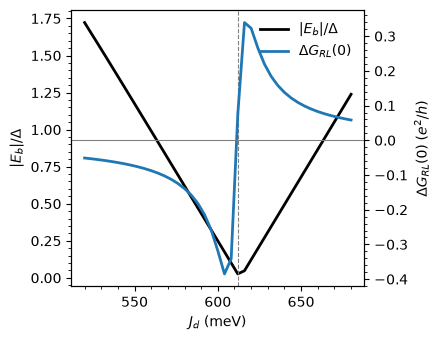

In [24]:
fig, ax1 = plt.subplots(figsize=(4.5, 3.5))


# Bound-state energy
line1 = ax1.plot(
    J_corr, Eb_square / Delta,
    color="black", lw=2,
    label=r"$|E_b|/\Delta$"
)

ax1.set_xlabel(r"$J_d$ (meV)")
ax1.set_ylabel(r"$|E_b|/\Delta$")

ax1.axvline(
    J_cross,
    color="gray", ls="--", lw=0.8
)


# Conductance response
ax2 = ax1.twinx()

line2 = ax2.plot(
    J_corr, dG_square_corr,
    lw=2,
    label=r"$\Delta G_{RL}(0)$"
)

ax2.axhline(0, color="gray", lw=0.8)

ax2.set_ylabel(
    r"$\Delta G_{RL}(0)\;(e^2/h)$"
)


lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(
    lines, labels,
    frameon=False,
    loc="upper right"
)

ax1.minorticks_on()
ax2.minorticks_on()

plt.tight_layout()

# plt.savefig(
#     FIG_DIR / "device_square_level_transport.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()